# Module 13: Deep Learning Based Object Detection
Unlike traditional object tracking (which follows a single known target from frame to frame), deep learning-based **Object Detection** simultaneously solves two complex computer vision problems: **Classification** (identifying *what* an object is) and **Localization** (finding exactly *where* it is by drawing a bounding box).

In this module, we implement a pre-trained **Single Shot MultiBox Detector (SSD)** paired with a **MobileNet** backbone architecture running on the TensorFlow framework.

In [8]:
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
from zipfile import ZipFile
from urllib.request import urlretrieve

%matplotlib inline

### 1. TensorFlow Object Detection Model Zoo Setup
Deep neural networks require substantial computing power to train from scratch. Instead, we utilize **Transfer Learning** by downloading a model pre-trained on the COCO (Common Objects in Context) dataset from the TensorFlow Model Zoo.

The setup verifies the existence of two critical files:
* **`frozen_inference_graph.pb` (Binary Graph):** The compiled structural layers and optimized mathematical weights of the trained neural network.
* **`ssd_mobilenet_v2_coco_2018_03_29.pbtxt` (Text Graph):** A text-based configuration file that maps the layout of the TensorFlow graph so that OpenCV's DNN module can parse and execute it correctly.

In [9]:
# Define paths first so the download check works
modelFile = os.path.join("models", "ssd_mobilenet_v2_coco_2018_03_29", "frozen_inference_graph.pb")
configFile = os.path.join("models", "ssd_mobilenet_v2_coco_2018_03_29.pbtxt")

if not os.path.isdir('models'):
    os.mkdir("models")

if not os.path.isfile(modelFile):
    os.chdir("models")
    print("Downloading the TensorFlow Model...")
    # Download the tensorflow Model
    urlretrieve('http://download.tensorflow.org/models/object_detection/ssd_mobilenet_v2_coco_2018_03_29.tar.gz', 'ssd_mobilenet_v2_coco_2018_03_29.tar.gz')

    print("Uncompressing files...")
    # Uncompress the file
    !tar -xvf ssd_mobilenet_v2_coco_2018_03_29.tar.gz

    # Delete the archive archive
    os.remove('ssd_mobilenet_v2_coco_2018_03_29.tar.gz')
    
    # Return to project root directory
    os.chdir("..")
    print("Model setup complete.")
else:
    print("Model files already exist locally.")

Model files already exist locally.


### 2. Downloading Evaluation Assets
We download the testing image package (`opencv_bootcamp_assets_NB13.zip`) containing high-resolution target images, such as `street.jpg`, which contain a variety of everyday objects to evaluate our detection model's performance.

In [10]:
def download_and_unzip(url, save_path):
    print(f"Downloading and extracting assets....", end="")
    urlretrieve(url, save_path)
    try:
        with ZipFile(save_path) as z:
            z.extractall(os.path.split(save_path)[0])
        print("Done")
    except Exception as e:
        print("\nInvalid file.", e)

URL = r"https://www.dropbox.com/s/xoomeq2ids9551y/opencv_bootcamp_assets_NB13.zip?dl=1"
asset_zip_path = os.path.join(os.getcwd(), "opencv_bootcamp_assets_NB13.zip")

if not os.path.exists(asset_zip_path):
    download_and_unzip(URL, asset_zip_path)
else:
    print("Assets already extracted.")

Assets already extracted.


### 3. Loading the COCO Dataset Class Labels
The SSD MobileNet model was trained on the **COCO Dataset**, which contains 90 distinct object categories (ranging from pedestrians, cars, and bicycles to common indoor items like cups and laptops). We read these labels from a text file into a Python list so we can map the network's numerical predictions back to human-readable strings.

In [11]:
classFile = "coco_class_labels.txt"
with open(classFile) as fp:
    labels = fp.read().split("\n")

print(f"Successfully loaded {len(labels)} class labels.")
print(labels)

Successfully loaded 93 class labels.
['unlabeled', 'person', 'bicycle', 'car', 'motorcycle', 'airplane', 'bus', 'train', 'truck', 'boat', 'traffic light', 'fire hydrant', 'street sign', 'stop sign', 'parking meter', 'bench', 'bird', 'cat', 'dog', 'horse', 'sheep', 'cow', 'elephant', 'bear', 'zebra', 'giraffe', 'hat', 'backpack', 'umbrella', 'shoe', 'eye glasses', 'handbag', 'tie', 'suitcase', 'frisbee', 'skis', 'snowboard', 'sports ball', 'kite', 'baseball bat', 'baseball glove', 'skateboard', 'surfboard', 'tennis racket', 'bottle', 'plate', 'wine glass', 'cup', 'fork', 'knife', 'spoon', 'bowl', 'banana', 'apple', 'sandwich', 'orange', 'broccoli', 'carrot', 'hot dog', 'pizza', 'donut', 'cake', 'chair', 'couch', 'potted plant', 'bed', 'mirror', 'dining table', 'window', 'desk', 'toilet', 'door', 'tv', 'laptop', 'mouse', 'remote', 'keyboard', 'cell phone', 'microwave', 'oven', 'toaster', 'sink', 'refrigerator', 'blender', 'book', 'clock', 'vase', 'scissors', 'teddy bear', 'hair drier', '

### 4. Compiling the Network via OpenCV DNN
OpenCV features a highly optimized **DNN (Deep Neural Network)** module specifically built for running inference on pre-trained third-party models. We use `cv2.dnn.readNetFromTensorflow` to load the binary weights and structure directly into system memory, preparing the pipeline for high-speed forward passes.

In [12]:
modelFile  = os.path.join("models", "ssd_mobilenet_v2_coco_2018_03_29", "frozen_inference_graph.pb")
configFile = os.path.join("models", "ssd_mobilenet_v2_coco_2018_03_29.pbtxt")

In [13]:
# Read the network architecture configuration
net = cv2.dnn.readNetFromTensorflow(modelFile, configFile)
print("TensorFlow SSD MobileNet architecture successfully loaded into memory.")

TensorFlow SSD MobileNet architecture successfully loaded into memory.


### 5. Image Preprocessing & Spatial Inference Functions
Neural networks cannot ingest raw images directly; the data must be standardized first.

* **Image-to-Blob Conversion (`cv2.dnn.blobFromImage`):** This resizes the input image to a fixed dimensions matrix ($300 \times 300$ pixels), normalizes pixel intensities, performs mean subtraction to eliminate lighting biases, and swaps the Blue and Red channels to convert standard OpenCV BGR layouts to the RGB format expected by TensorFlow.
* **The Forward Pass (`net.forward()`):** This pushes the preprocessed blob through the architecture layers to generate a multidimensional array containing detection indices, confidence values, and normalized coordinates.
* **Coordinate De-normalization:** The network outputs location coordinates as percentages (between `0.0` and `1.0`). We map these values back against the original image's pixel width and height to plot precise bounding boxes.

In [14]:
FONTFACE = cv2.FONT_HERSHEY_SIMPLEX
FONT_SCALE = 0.7
THICKNESS = 1

def detect_objects(net, im, dim=300):
    # Convert image frame to structural blob format expected by SSD model
    blob = cv2.dnn.blobFromImage(im, 1.0, size=(dim, dim), mean=(0, 0, 0), swapRB=True, crop=False)
    net.setInput(blob)
    objects = net.forward()
    return objects

def display_text(im, text, x, y):
    textSize = cv2.getTextSize(text, FONTFACE, FONT_SCALE, THICKNESS)
    dim = textSize[0]
    baseline = textSize[1]

    # Plot background anchor container
    cv2.rectangle(
        im,
        (x, y - dim[1] - baseline),
        (x + dim[0], y + baseline),
        (0, 0, 0),
        cv2.FILLED,
    )
    # Overlay label string
    cv2.putText(
        im,
        text,
        (x, y - 5),
        FONTFACE,
        FONT_SCALE,
        (0, 255, 255),
        THICKNESS,
        cv2.LINE_AA,
    )

def display_objects(im, objects, threshold=0.25):
    rows = im.shape[0]
    cols = im.shape[1]

    # Iterate through every prediction index within the array
    for i in range(objects.shape[2]):
        classId = int(objects[0, 0, i, 1])
        score = float(objects[0, 0, i, 2])

        # De-normalize coordinates back to pixel dimensional spacing
        x = int(objects[0, 0, i, 3] * cols)
        y = int(objects[0, 0, i, 4] * rows)
        w = int(objects[0, 0, i, 5] * cols - x)
        h = int(objects[0, 0, i, 6] * rows - y)

        if score > threshold:
            display_text(im, "{}".format(labels[classId]), x, y)
            cv2.rectangle(im, (x, y), (x + w, y + h), (255, 255, 255), 2)

    # Convert BGR layout array to RGB formatting for matplotlib visualization
    mp_img = cv2.cvtColor(im, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=(30, 10))
    plt.imshow(mp_img)
    plt.axis('off')
    plt.show()

### 6. Executing Inference and Evaluating Results
We load our test image, execute a single forward pass through our compiled network, and filter the predictions. 

To eliminate weak background noise and false positives, we implement a **Confidence Threshold of 25% (`threshold=0.25`)**. Only detections where the AI model is at least 25% confident will have their labels and bounding boxes overlaid onto the final Matplotlib visualization.

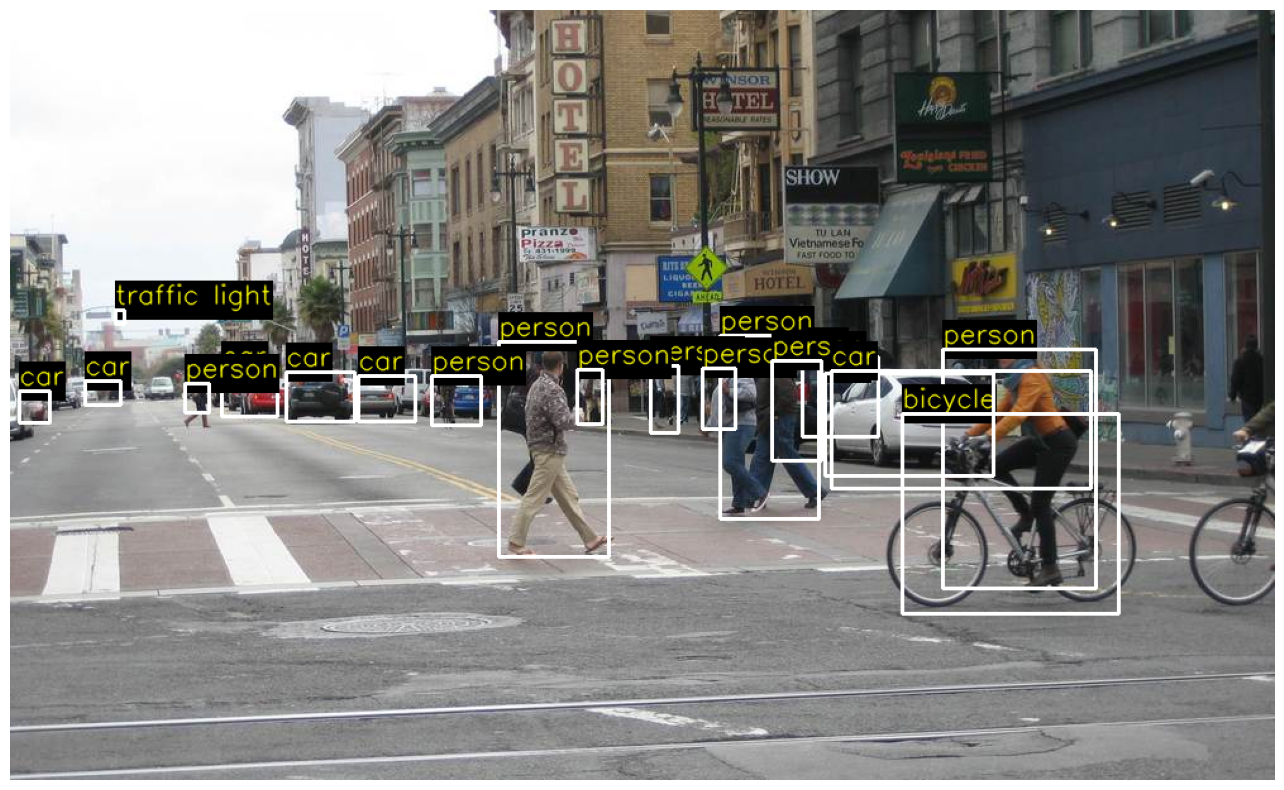

In [15]:
im = cv2.imread(os.path.join("images", "street.jpg"))
objects = detect_objects(net, im)
display_objects(im, objects)

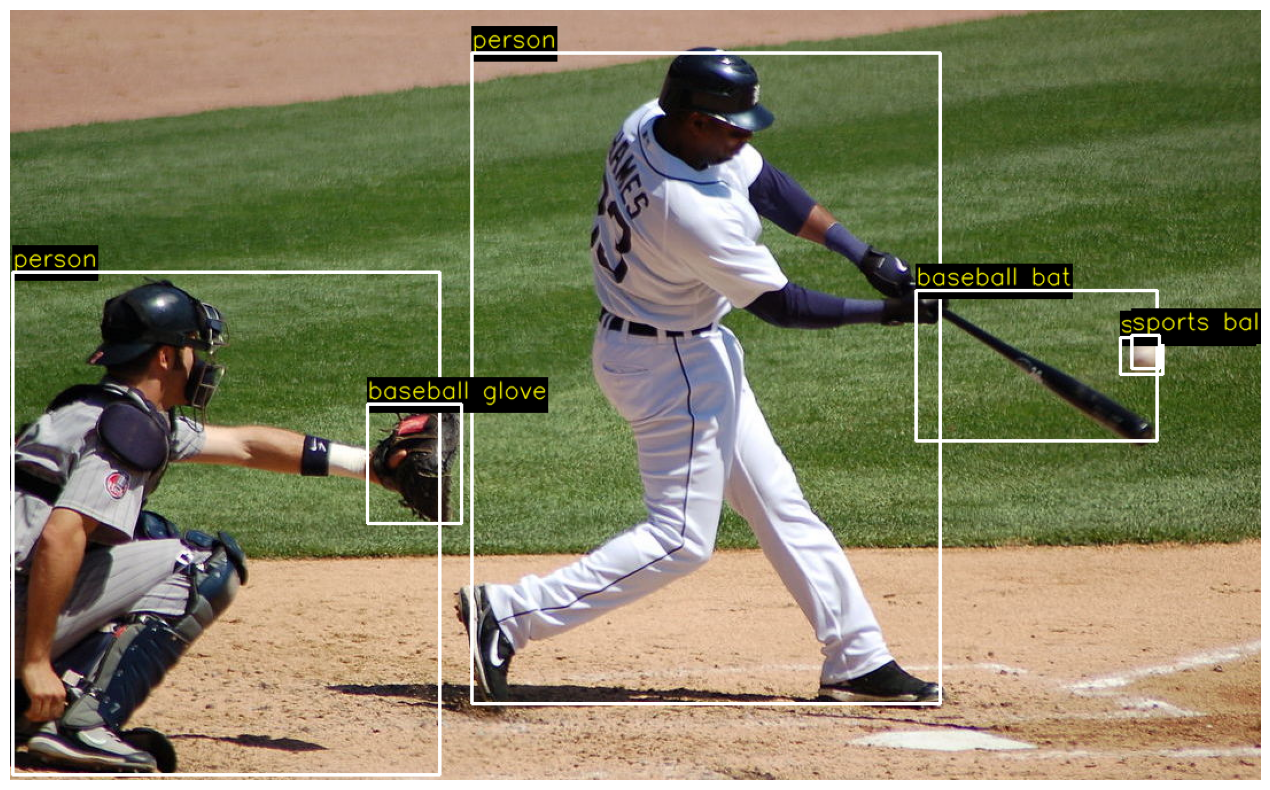

In [16]:
im = cv2.imread(os.path.join("images", "baseball.jpg"))
objects = detect_objects(net, im)
display_objects(im, objects, 0.2)

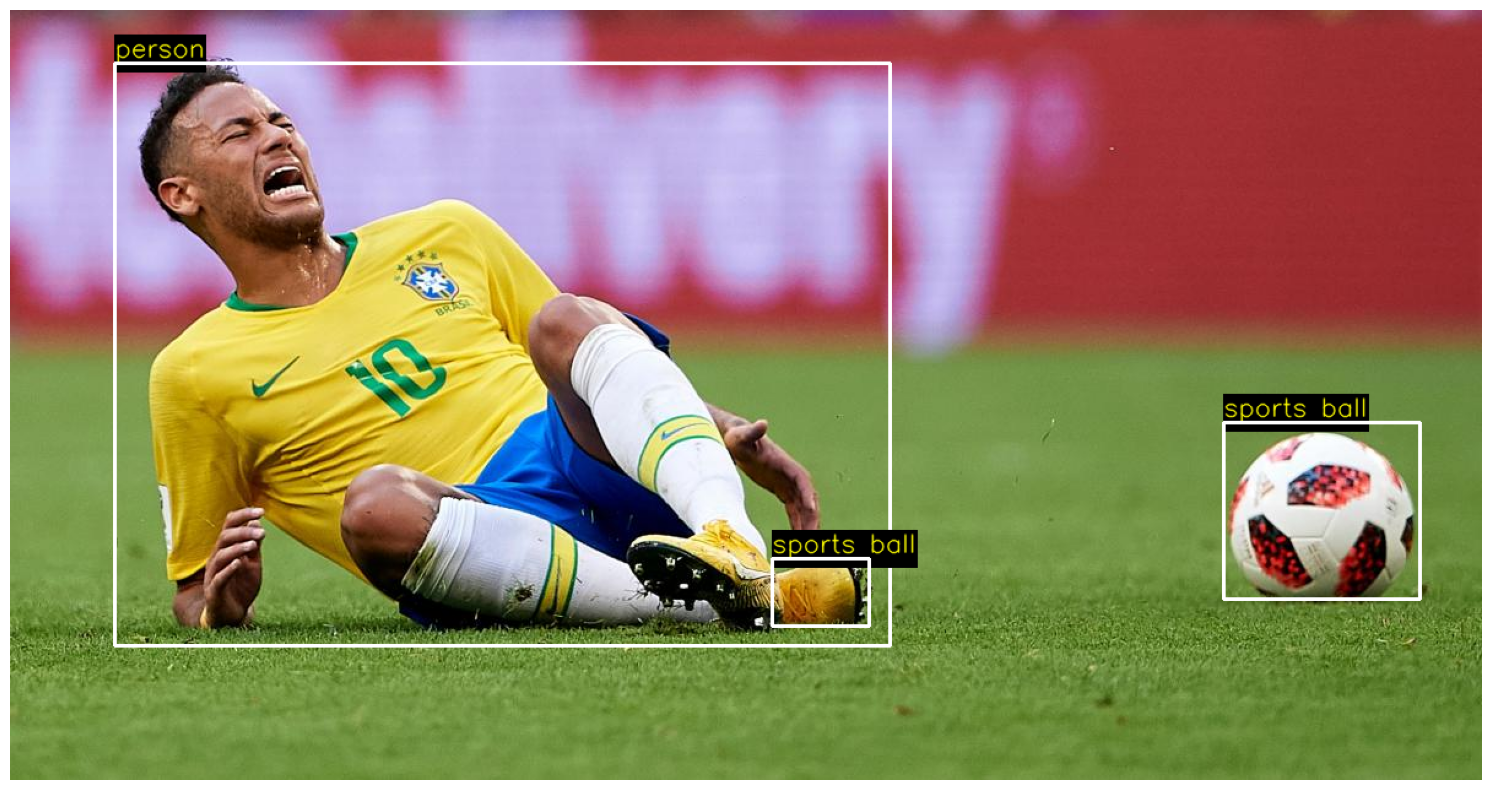

In [17]:
im = cv2.imread(os.path.join("images", "soccer.jpg"))
objects = detect_objects(net, im)
display_objects(im, objects)